In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [26]:
df=pd.read_csv("C:\\Users\\Rajaharshini Arepati\\Downloads\\RF datasets.csv")

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   salary                 1000 non-null   float64
 2   experience_years       1000 non-null   int64  
 3   education_level        1000 non-null   object 
 4   department             1000 non-null   object 
 5   city_tier              1000 non-null   object 
 6   work_hours_per_week    1000 non-null   int64  
 7   performance_score      1000 non-null   float64
 8   promotion_last_5years  1000 non-null   int64  
 9   target_left_company    1000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 78.3+ KB


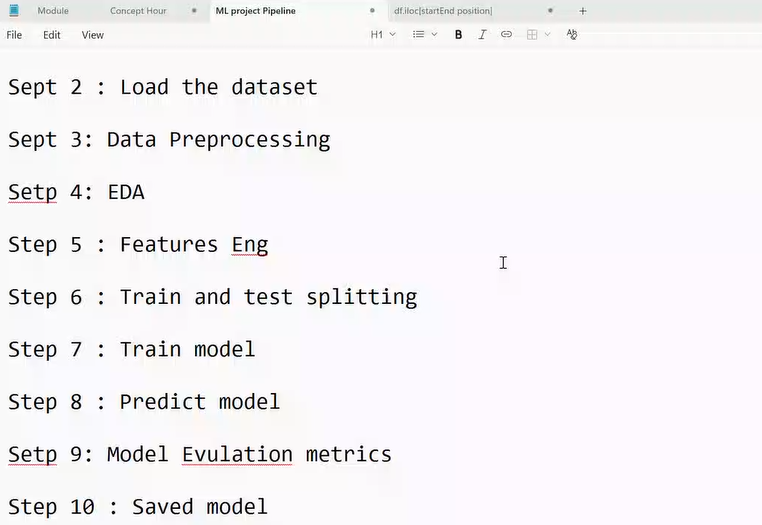

In [28]:
df.isnull().sum()

age                      0
salary                   0
experience_years         0
education_level          0
department               0
city_tier                0
work_hours_per_week      0
performance_score        0
promotion_last_5years    0
target_left_company      0
dtype: int64

In [29]:
df['department'].value_counts()

department
IT            225
Finance       201
Operations    199
HR            190
Marketing     185
Name: count, dtype: int64

In [30]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(sparse_output=False,drop='first')
categorical_cols=['city_tier','department','education_level']
ohe_df=pd.DataFrame(ohe.fit_transform(df[categorical_cols]),columns=ohe.get_feature_names_out(categorical_cols))

In [31]:
import pandas as pd
df=pd.concat([df.drop(columns=categorical_cols),ohe_df],axis=1)
df.head()

,age,salary,experience_years,work_hours_per_week,performance_score,promotion_last_5years,target_left_company,city_tier_Tier-2,city_tier_Tier-3,department_HR,department_IT,department_Marketing,department_Operations,education_level_High School,education_level_Master,education_level_PhD
0,56,136748.0,33,47,3.800000,0,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,46,25287.0,28,40,2.400000,1,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,32,146593.0,3,45,2.970316,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,60,54387.0,16,47,2.600000,0,0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,25,28512.0,34,64,1.900000,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
X=df.drop(columns=["target_left_company"])
y=df["target_left_company"]
X=X.astype(int)

In [35]:
from sklearn.model_selection import train_test_split        
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
model=rf_model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_pred


array([1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0])

In [38]:
comparison_df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
comparison_df.head(10)

,Actual,Predicted
521,1,1
737,0,1
740,0,1
660,0,1
411,0,0
678,1,0
626,0,1
513,0,1
859,0,0
136,1,1


In [39]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.52
[[56 34]
 [62 48]]
              precision    recall  f1-score   support

           0       0.47      0.62      0.54        90
           1       0.59      0.44      0.50       110

    accuracy                           0.52       200
   macro avg       0.53      0.53      0.52       200
weighted avg       0.54      0.52      0.52       200

